# Dataset Statistics — Atom Type Distributions

Distribution of atom types for **pocket** (4 types: C, O, N, S), **ligand** (7 types: C, O, N, S, F, Cl, P), and combined.

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

import torch
import numpy as np
import matplotlib.pyplot as plt

from voxbind.constants import ELEMENTS_HASH_CROSSDOCKED, N_POCKET_ELEMENTS, N_LIGAND_ELEMENTS

In [3]:
DATA_DIR = os.path.join(os.getcwd(), "..", "voxbind", "dataset", "data")

data_train = torch.load(os.path.join(DATA_DIR, "data_train.pt"), weights_only=False)
data_test  = torch.load(os.path.join(DATA_DIR, "data_test.pt"),  weights_only=False)
data_all   = data_train + data_test

IDX_TO_ELEM = {v: k for k, v in ELEMENTS_HASH_CROSSDOCKED.items()}
POCKET_ELEMS = [IDX_TO_ELEM[i] for i in range(N_POCKET_ELEMENTS)]  # C, O, N, S
LIGAND_ELEMS = [IDX_TO_ELEM[i] for i in range(N_LIGAND_ELEMENTS)]  # C, O, N, S, F, Cl, P

print(f"Train: {len(data_train)},  Test: {len(data_test)},  Total: {len(data_all)}")
print(f"Pocket elements ({N_POCKET_ELEMENTS}): {POCKET_ELEMS}")
print(f"Ligand elements ({N_LIGAND_ELEMENTS}): {LIGAND_ELEMS}")

Train: 99981,  Test: 100,  Total: 100081
Pocket elements (4): ['C', 'O', 'N', 'S']
Ligand elements (7): ['C', 'O', 'N', 'S', 'F', 'Cl', 'P']


In [4]:
# ── Count atoms across all samples ────────────────────────────────────
poc_counts = np.zeros(N_POCKET_ELEMENTS, dtype=np.int64)
lig_counts = np.zeros(N_LIGAND_ELEMENTS, dtype=np.int64)

for poc, lig in data_all:
    ch = poc["atoms_channel"].numpy()
    for i in range(N_POCKET_ELEMENTS):
        poc_counts[i] += (ch == i).sum()
    ch = lig["atoms_channel"].numpy()
    for i in range(N_LIGAND_ELEMENTS):
        lig_counts[i] += (ch == i).sum()

print("Pocket atom counts:", dict(zip(POCKET_ELEMS, poc_counts)))
print("Ligand atom counts:", dict(zip(LIGAND_ELEMS, lig_counts)))

Pocket atom counts: {'C': np.int64(25501033), 'O': np.int64(7287508), 'N': np.int64(6580418), 'S': np.int64(283466)}
Ligand atom counts: {'C': np.int64(1586262), 'O': np.int64(400726), 'N': np.int64(276504), 'S': np.int64(26552), 'F': np.int64(30875), 'Cl': np.int64(15221), 'P': np.int64(26331)}


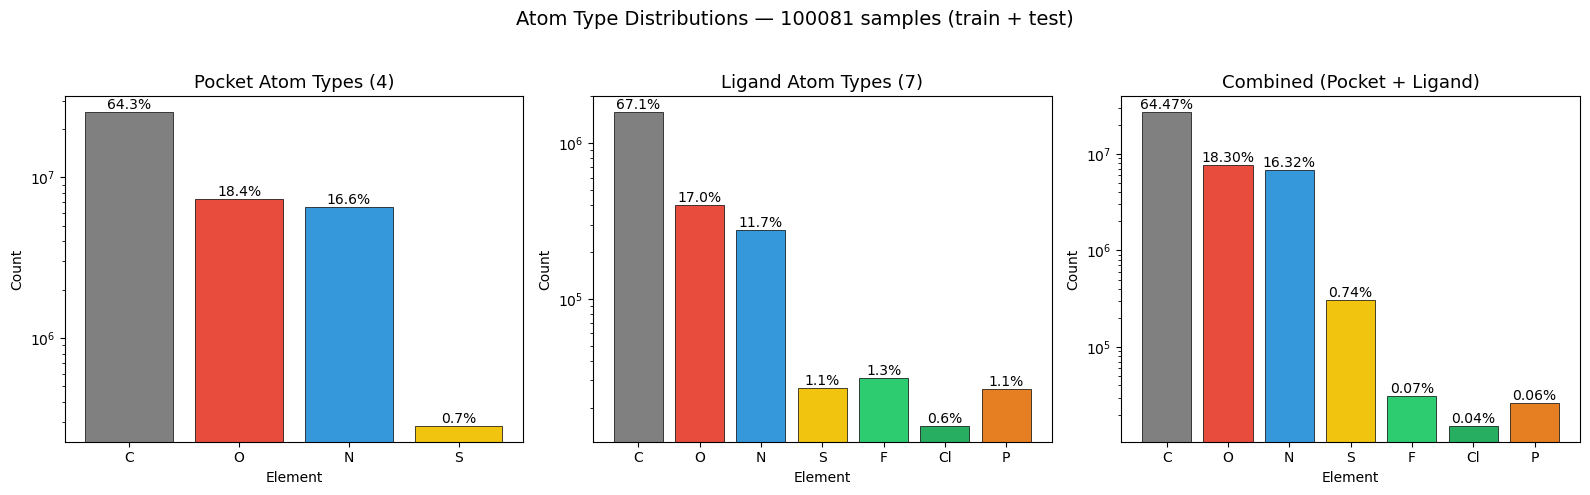

In [13]:
ELEM_COLORS = {"C": "#808080", "O": "#e74c3c", "N": "#3498db", "S": "#f1c40f", "F": "#2ecc71", "Cl": "#27ae60", "P": "#e67e22"}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Pocket ────────────────────────────────────────────────────────────
poc_pct = poc_counts / poc_counts.sum() * 100
colors_poc = [ELEM_COLORS[e] for e in POCKET_ELEMS]
bars = axes[0].bar(POCKET_ELEMS, poc_counts, color=colors_poc, edgecolor="black", linewidth=0.5)
for bar, pct in zip(bars, poc_pct):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{pct:.1f}%", ha="center", va="bottom", fontsize=10)
axes[0].set_yscale("log")
axes[0].set_title("Pocket Atom Types (4)", fontsize=13)
axes[0].set_ylabel("Count")
axes[0].set_xlabel("Element")

# ── Ligand ────────────────────────────────────────────────────────────
lig_pct = lig_counts / lig_counts.sum() * 100
colors_lig = [ELEM_COLORS[e] for e in LIGAND_ELEMS]
bars = axes[1].bar(LIGAND_ELEMS, lig_counts, color=colors_lig, edgecolor="black", linewidth=0.5)
for bar, pct in zip(bars, lig_pct):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{pct:.1f}%", ha="center", va="bottom", fontsize=10)
axes[1].set_yscale("log")
axes[1].set_title("Ligand Atom Types (7)", fontsize=13)
axes[1].set_ylabel("Count")
axes[1].set_xlabel("Element")

# ── Combined ──────────────────────────────────────────────────────────
all_elems = LIGAND_ELEMS  # superset (7 elements)
comb_counts = np.zeros(N_LIGAND_ELEMENTS, dtype=np.int64)
for i in range(N_POCKET_ELEMENTS):
    comb_counts[i] += poc_counts[i]
for i in range(N_LIGAND_ELEMENTS):
    comb_counts[i] += lig_counts[i]

comb_pct = comb_counts / comb_counts.sum() * 100
colors_all = [ELEM_COLORS[e] for e in all_elems]
bars = axes[2].bar(all_elems, comb_counts, color=colors_all, edgecolor="black", linewidth=0.5)
for bar, pct in zip(bars, comb_pct):
    axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{pct:.2f}%", ha="center", va="bottom", fontsize=10)
axes[2].set_yscale("log")
axes[2].set_title("Combined (Pocket + Ligand)", fontsize=13)
axes[2].set_ylabel("Count")
axes[2].set_xlabel("Element")

fig.suptitle(f"Atom Type Distributions — {len(data_all)} samples (train + test)", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Generated samples — VoxBind (cbgbench)

Atom type distribution from the **generated** ligand SDF files under `exps/cbgbench/voxbind/`, compared with the **dataset** ligand distribution.

In [6]:
from glob import glob
from rdkit import Chem
from collections import Counter

GEN_DIR = os.path.join(os.getcwd(), "..", "voxbind", "exps", "cbgbench", "voxbind")
sdf_files = sorted(glob(os.path.join(GEN_DIR, "**", "samples_*.sdf"), recursive=True))
print(f"Found {len(sdf_files)} generated SDF files")

# count atoms by element symbol
gen_elem_counter = Counter()
n_parsed = 0
for sdf_path in sdf_files:
    try:
        suppl = Chem.SDMolSupplier(sdf_path, sanitize=False, removeHs=True)
        for mol in suppl:
            if mol is None:
                continue
            for atom in mol.GetAtoms():
                gen_elem_counter[atom.GetSymbol()] += 1
            n_parsed += 1
    except Exception:
        continue

print(f"Parsed {n_parsed} molecules")
print(f"Atom counts: {dict(gen_elem_counter.most_common())}")

Found 6651 generated SDF files


[11:42:49] atom 15 has specified valence (1) smaller than the drawn valence 2.
[11:42:49] atom 22 has specified valence (3) smaller than the drawn valence 4.
[11:42:49] atom 19 has specified valence (1) smaller than the drawn valence 2.
[11:42:49] atom 13 has specified valence (3) smaller than the drawn valence 4.
[11:42:49] atom 2 has specified valence (1) smaller than the drawn valence 2.
[11:42:49] atom 6 has specified valence (4) smaller than the drawn valence 5.
[11:42:49] atom 0 has specified valence (1) smaller than the drawn valence 2.
[11:42:49] atom 2 has specified valence (1) smaller than the drawn valence 2.
[11:42:49] atom 7 has specified valence (4) smaller than the drawn valence 5.
[11:42:49] atom 8 has specified valence (4) smaller than the drawn valence 5.
[11:42:49] atom 7 has specified valence (1) smaller than the drawn valence 2.
[11:42:49] atom 13 has specified valence (4) smaller than the drawn valence 5.
[11:42:49] atom 3 has specified valence (1) smaller than th

Parsed 6650 molecules
Atom counts: {'C': 109859, 'O': 20751, 'N': 16168, 'S': 1792, 'P': 693, 'Cl': 11}


[11:42:50] atom 12 has specified valence (1) smaller than the drawn valence 2.
[11:42:50] atom 18 has specified valence (4) smaller than the drawn valence 5.
[11:42:50] atom 10 has specified valence (1) smaller than the drawn valence 2.
[11:42:50] atom 15 has specified valence (1) smaller than the drawn valence 2.
[11:42:50] atom 16 has specified valence (1) smaller than the drawn valence 2.
[11:42:50] atom 23 has specified valence (4) smaller than the drawn valence 5.
[11:42:50] atom 24 has specified valence (4) smaller than the drawn valence 5.
[11:42:50] atom 25 has specified valence (4) smaller than the drawn valence 5.
[11:42:50] atom 16 has specified valence (1) smaller than the drawn valence 2.
[11:42:50] atom 21 has specified valence (4) smaller than the drawn valence 5.
[11:42:50] atom 16 has specified valence (1) smaller than the drawn valence 2.
[11:42:50] atom 23 has specified valence (4) smaller than the drawn valence 5.
[11:42:50] atom 17 has specified valence (1) smaller

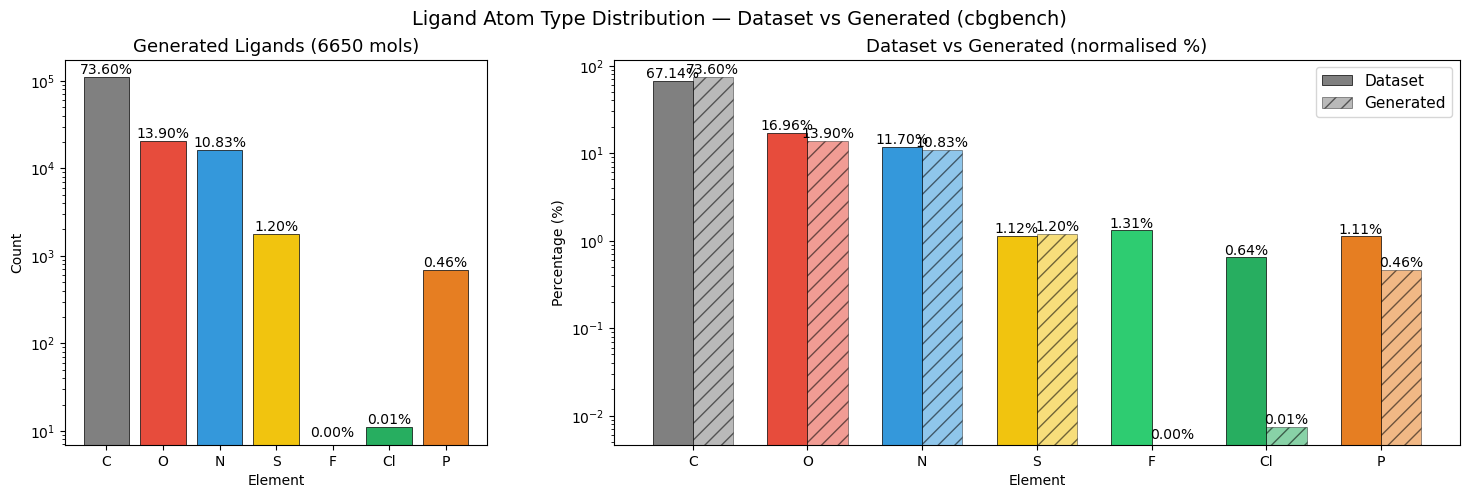

In [42]:
# ── Map generated counts to the same 7-element order as the dataset ───
gen_lig_counts = np.array([gen_elem_counter.get(e, 0) for e in LIGAND_ELEMS], dtype=np.int64)

# also report any unexpected elements
known = set(LIGAND_ELEMS)
extra = {k: v for k, v in gen_elem_counter.items() if k not in known}
if extra:
    print(f"Extra elements in generated (not in ligand channels): {extra}")

fig, axes = plt.subplots(1, 2, figsize=(18, 5), gridspec_kw={"width_ratios": [1, 2]})

# ── Left: generated ligand distribution ───────────────────────────────
gen_pct = gen_lig_counts / gen_lig_counts.sum() * 100
colors_lig = [ELEM_COLORS[e] for e in LIGAND_ELEMS]
bars = axes[0].bar(LIGAND_ELEMS, gen_lig_counts, color=colors_lig, edgecolor="black", linewidth=0.5)
for bar, pct in zip(bars, gen_pct):
	if pct < 0.001:
		axes[0].text(bar.get_x() + bar.get_width() / 2, 8, f"{pct:.2f}%", ha="center", va="bottom", fontsize=10)
	else:
		axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{pct:.2f}%", ha="center", va="bottom", fontsize=10)
axes[0].set_yscale("log")
axes[0].set_title(f"Generated Ligands ({n_parsed} mols)", fontsize=13)
axes[0].set_ylabel("Count")
axes[0].set_xlabel("Element")

# ── Right: side-by-side comparison (dataset vs generated, normalised) ─
x = np.arange(len(LIGAND_ELEMS))
w = 0.35
dataset_pct = lig_counts / lig_counts.sum() * 100

bars1 = axes[1].bar(x - w/2, dataset_pct, w, color=[ELEM_COLORS[e] for e in LIGAND_ELEMS], edgecolor="black", linewidth=0.5, label="Dataset")
bars2 = axes[1].bar(x + w/2, gen_pct, w, color=[ELEM_COLORS[e] for e in LIGAND_ELEMS], edgecolor="black", linewidth=0.5, alpha=0.55, label="Generated", hatch="//")
for i, (bar, pct) in enumerate(zip(bars1, dataset_pct)):
    if pct < 0.001:
        axes[1].text(bar.get_x() + bar.get_width() / 2, 0.005, f"{pct:.2f}%", ha="center", va="bottom", fontsize=10)
    else:
        axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{pct:.2f}%", ha="center", va="bottom", fontsize=10)
for i, (bar, pct) in enumerate(zip(bars2, gen_pct)):
    if pct < 0.001:
        axes[1].text(bar.get_x() + bar.get_width() / 2, 0.005, f"{pct:.2f}%", ha="center", va="bottom", fontsize=10)
    else:
        axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{pct:.2f}%", ha="center", va="bottom", fontsize=10)
axes[1].set_xticks(x)
axes[1].set_xticklabels(LIGAND_ELEMS)
axes[1].set_yscale("log")
axes[1].set_title("Dataset vs Generated (normalised %)", fontsize=13)
axes[1].set_ylabel("Percentage (%)")
axes[1].set_xlabel("Element")
axes[1].legend(fontsize=11)

fig.suptitle("Ligand Atom Type Distribution — Dataset vs Generated (cbgbench)", fontsize=14)
# fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Dataset ligand atom distribution

In [ ]:
from collections import defaultdict

def get_protein_name(poc_id):
    """Extract protein family name from pocket ID, e.g. 'DYR_STAAU_2_158_0/...' → 'DYR'."""
    return poc_id.split('/')[0].split('_')[0]

# ── Accumulate per-protein ligand atom counts ──────────────────────────
protein_lig_counts = defaultdict(lambda: np.zeros(N_LIGAND_ELEMENTS, dtype=np.int64))
protein_sample_counts = Counter()

for poc, lig in data_all:
    prot = get_protein_name(poc['id'])
    protein_sample_counts[prot] += 1
    ch = lig['atoms_channel'].numpy()
    for i in range(N_LIGAND_ELEMENTS):
        protein_lig_counts[prot][i] += (ch == i).sum()

# ── Select top-N proteins by sample count ─────────────────────────────
TOP_N = 40
top_proteins = [p for p, _ in protein_sample_counts.most_common(TOP_N)]

# Build matrix: rows = proteins, cols = ligand elements
mat = np.array([protein_lig_counts[p] for p in top_proteins], dtype=np.float64)
# Normalise each row to percentages
row_totals = mat.sum(axis=1, keepdims=True)
mat_pct = mat / row_totals * 100  # shape (TOP_N, 7)

sample_ns = [protein_sample_counts[p] for p in top_proteins]
row_labels = [f"{p} (n={n:,})" for p, n in zip(top_proteins, sample_ns)]

print(f"Matrix shape: {mat_pct.shape}  (proteins × ligand elements)")
print(f"Elements: {LIGAND_ELEMS}")

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ── Heatmap ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 14))

im = ax.imshow(mat_pct, aspect="auto", cmap="YlOrRd")
cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Atom fraction (%)", fontsize=11)

ax.set_xticks(range(N_LIGAND_ELEMENTS))
ax.set_xticklabels(LIGAND_ELEMS, fontsize=12)
ax.set_yticks(range(TOP_N))
ax.set_yticklabels(row_labels, fontsize=9)
ax.set_title(f"Ligand Atom-Type Distribution per Target Protein\n(top {TOP_N} by sample count)", fontsize=13)
ax.set_xlabel("Ligand element", fontsize=11)

# Annotate cells
for i in range(TOP_N):
    for j in range(N_LIGAND_ELEMENTS):
        val = mat_pct[i, j]
        text_color = "white" if val > 55 else "black"
        ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=7, color=text_color)

plt.tight_layout()
plt.show()

In [43]:

# Inspect the first few samples to understand the data structure
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

import torch
import numpy as np

DATA_DIR = os.path.join(os.getcwd(), "..", "voxbind", "dataset", "data")
data_train = torch.load(os.path.join(DATA_DIR, "data_train.pt"), weights_only=False)
data_test  = torch.load(os.path.join(DATA_DIR, "data_test.pt"),  weights_only=False)

# Look at first sample's keys
poc, lig = data_train[0]
print("Pocket keys:", poc.keys() if hasattr(poc, 'keys') else type(poc))
print("Ligand keys:", lig.keys() if hasattr(lig, 'keys') else type(lig))
print()
print("Sample poc:", poc)
print()
print("Sample lig:", lig)


Pocket keys: dict_keys(['id', 'coords', 'atoms_channel'])
Ligand keys: dict_keys(['id', 'coords', 'atoms_channel', 'max_len'])

Sample poc: {'id': 'DYR_STAAU_2_158_0/4xe6_X_rec_3fqc_55v_lig_tt_docked_4_pocket10.pdb', 'coords': tensor([[ -2.4620, -25.1450,  -0.6010],
        [ -3.7220, -25.5020,   0.0470],
        [ -3.4760, -25.7460,   1.5290],
        ...,
        [  0.9150, -21.7480,   3.7040],
        [  0.7870, -19.4010,   4.1140],
        [  0.8000, -20.4650,   3.2270]]), 'atoms_channel': tensor([2, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 1, 0, 0, 0, 2, 0, 0, 1, 0, 2, 0, 0, 1,
        0, 0, 0, 0, 2, 0, 0, 1, 2, 0, 0, 1, 0, 0, 1, 2, 2, 0, 0, 1, 0, 0, 0, 1,
        2, 2, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 1, 0, 0, 0, 2, 0, 0, 1, 0, 0, 0, 0,
        2, 0, 0, 0, 0, 0, 2, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 1, 0, 0, 0, 2, 0, 0,
        1, 0, 0, 3, 0, 2, 0, 0, 1, 2, 0, 0, 1, 0, 1, 0, 2, 0, 0, 1, 0, 0, 0, 0,
        0, 0, 0, 2, 0, 0, 1, 0, 1, 2, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 1, 0, 0, 0,
        0, 2, 0, 0, 1

In [46]:

from collections import defaultdict, Counter
from voxbind.constants import ELEMENTS_HASH_CROSSDOCKED, N_POCKET_ELEMENTS, N_LIGAND_ELEMENTS

IDX_TO_ELEM = {v: k for k, v in ELEMENTS_HASH_CROSSDOCKED.items()}
POCKET_ELEMS = [IDX_TO_ELEM[i] for i in range(N_POCKET_ELEMENTS)]
LIGAND_ELEMS = [IDX_TO_ELEM[i] for i in range(N_LIGAND_ELEMENTS)]

def get_protein_name(poc_id):
    return poc_id.split('/')[0].split('_')[0]

protein_lig_counts = defaultdict(lambda: np.zeros(N_LIGAND_ELEMENTS, dtype=np.int64))
protein_sample_counts = Counter()

for poc, lig in data_all:
    prot = get_protein_name(poc['id'])
    protein_sample_counts[prot] += 1
    ch = lig['atoms_channel'].numpy()
    for i in range(N_LIGAND_ELEMENTS):
        protein_lig_counts[prot][i] += (ch == i).sum()

TOP_N = 40
top_proteins = [p for p, _ in protein_sample_counts.most_common(TOP_N)]

mat = np.array([protein_lig_counts[p] for p in top_proteins], dtype=np.float64)
row_totals = mat.sum(axis=1, keepdims=True)
mat_pct = mat / row_totals * 100

sample_ns = [protein_sample_counts[p] for p in top_proteins]
row_labels = [f"{p} (n={n:,})" for p, n in zip(top_proteins, sample_ns)]

print(f"Matrix shape: {mat_pct.shape}")
print(f"Elements: {LIGAND_ELEMS}")


Matrix shape: (40, 7)
Elements: ['C', 'O', 'N', 'S', 'F', 'Cl', 'P']


In [47]:

import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, Counter

from voxbind.constants import ELEMENTS_HASH_CROSSDOCKED, N_POCKET_ELEMENTS, N_LIGAND_ELEMENTS

DATA_DIR = os.path.join(os.getcwd(), "..", "voxbind", "dataset", "data")
data_train = torch.load(os.path.join(DATA_DIR, "data_train.pt"), weights_only=False)
data_test  = torch.load(os.path.join(DATA_DIR, "data_test.pt"),  weights_only=False)
data_all   = data_train + data_test

IDX_TO_ELEM = {v: k for k, v in ELEMENTS_HASH_CROSSDOCKED.items()}
LIGAND_ELEMS = [IDX_TO_ELEM[i] for i in range(N_LIGAND_ELEMENTS)]

def get_protein_name(poc_id):
    return poc_id.split('/')[0].split('_')[0]

protein_lig_counts = defaultdict(lambda: np.zeros(N_LIGAND_ELEMENTS, dtype=np.int64))
protein_sample_counts = Counter()

for poc, lig in data_all:
    prot = get_protein_name(poc['id'])
    protein_sample_counts[prot] += 1
    ch = lig['atoms_channel'].numpy()
    for i in range(N_LIGAND_ELEMENTS):
        protein_lig_counts[prot][i] += (ch == i).sum()

TOP_N = 40
top_proteins = [p for p, _ in protein_sample_counts.most_common(TOP_N)]
mat = np.array([protein_lig_counts[p] for p in top_proteins], dtype=np.float64)
mat_pct = mat / mat.sum(axis=1, keepdims=True) * 100

sample_ns = [protein_sample_counts[p] for p in top_proteins]
row_labels = [f"{p} (n={n:,})" for p, n in zip(top_proteins, sample_ns)]

print(f"Done. Matrix shape: {mat_pct.shape},  elements: {LIGAND_ELEMS}")


Done. Matrix shape: (40, 7),  elements: ['C', 'O', 'N', 'S', 'F', 'Cl', 'P']


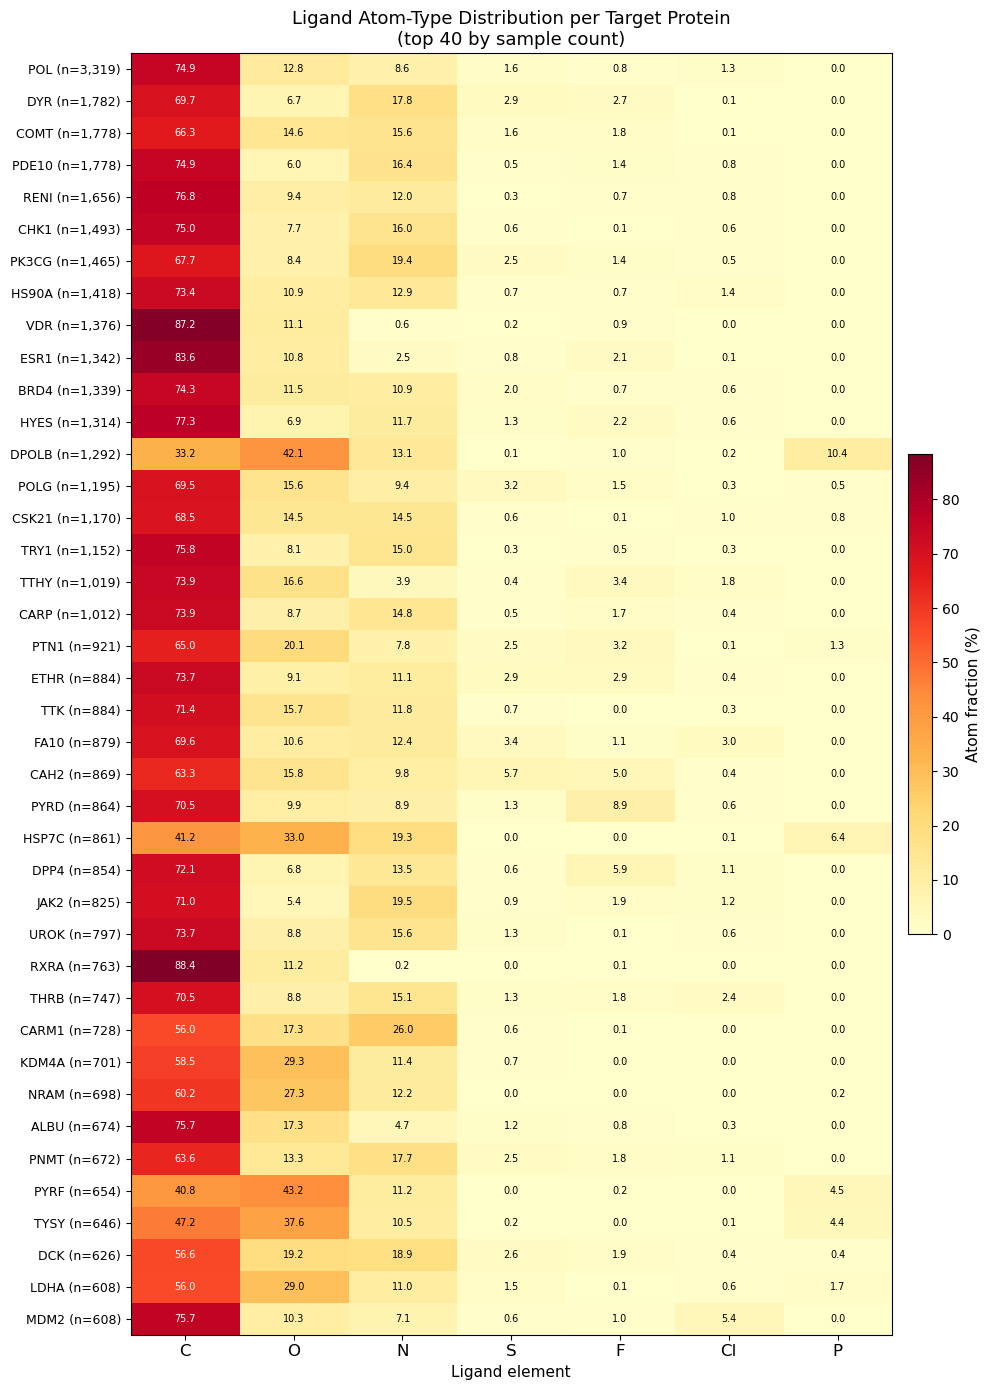

In [48]:

fig, ax = plt.subplots(figsize=(10, 14))

im = ax.imshow(mat_pct, aspect="auto", cmap="YlOrRd")
cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Atom fraction (%)", fontsize=11)

ax.set_xticks(range(N_LIGAND_ELEMENTS))
ax.set_xticklabels(LIGAND_ELEMS, fontsize=12)
ax.set_yticks(range(TOP_N))
ax.set_yticklabels(row_labels, fontsize=9)
ax.set_title(f"Ligand Atom-Type Distribution per Target Protein\n(top {TOP_N} by sample count)", fontsize=13)
ax.set_xlabel("Ligand element", fontsize=11)

for i in range(TOP_N):
    for j in range(N_LIGAND_ELEMENTS):
        val = mat_pct[i, j]
        text_color = "white" if val > 55 else "black"
        ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=7, color=text_color)

plt.tight_layout()
plt.show()


In [51]:

# Quick look at test set proteins
import torch, os, sys
import numpy as np
from collections import defaultdict, Counter

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
from voxbind.constants import ELEMENTS_HASH_CROSSDOCKED, N_POCKET_ELEMENTS, N_LIGAND_ELEMENTS

DATA_DIR = os.path.join(os.getcwd(), "..", "voxbind", "dataset", "data")
data_train = torch.load(os.path.join(DATA_DIR, "data_train.pt"), weights_only=False)
data_test  = torch.load(os.path.join(DATA_DIR, "data_test.pt"),  weights_only=False)

IDX_TO_ELEM = {v: k for k, v in ELEMENTS_HASH_CROSSDOCKED.items()}
LIGAND_ELEMS = [IDX_TO_ELEM[i] for i in range(N_LIGAND_ELEMENTS)]

def get_protein_name(poc_id):
    return poc_id.split('/')[0].split('_')[0]

# Count training samples per protein
train_protein_counts = Counter(get_protein_name(poc['id']) for poc, lig in data_train)

# Test proteins
test_proteins = [(get_protein_name(poc['id']), poc['id']) for poc, lig in data_test]
unique_test_proteins = list(dict.fromkeys(p for p, _ in test_proteins))
print(f"Test samples: {len(data_test)}")
print(f"Unique proteins in test: {len(unique_test_proteins)}")
print(f"\nTest proteins with 0 training samples:")
zero_train = [(p, train_protein_counts.get(p, 0)) for p in unique_test_proteins if train_protein_counts.get(p, 0) == 0]
print(zero_train)


Test samples: 100
Unique proteins in test: 93

Test proteins with 0 training samples:
[('BSD', 0), ('GLMU', 0), ('GRK4', 0), ('GSTP1', 0), ('GUX1', 0), ('HDAC8', 0), ('HDHA', 0), ('HMD', 0), ('CCPR', 0), ('IPMK', 0), ('CD38', 0), ('KS6A3', 0), ('CHOD', 0), ('LAT', 0), ('LMBL1', 0), ('M3K14', 0), ('MENE', 0), ('NEP', 0), ('NQO1', 0), ('NR1H4', 0), ('OLIAC', 0), ('PA21B', 0), ('PAK4', 0), ('PHKG1', 0), ('PHP', 0), ('COTA', 0), ('PLCD1', 0), ('PNTM', 0), ('CPXB', 0), ('PPIA', 0), ('PTGIS', 0), ('QPCT', 0), ('RIBB', 0), ('RG1', 0), ('ROCO4', 0), ('DPO4', 0), ('SDIA', 0), ('DPP2', 0), ('TBK1', 0), ('TRAR', 0), ('UBE2T', 0), ('VAOX', 0), ('XANLY', 0), ('EFTU1', 0), ('F16P1', 0), ('FKB1A', 0), ('IDHP', 0), ('IMA1', 0), ('MCCF', 0), ('MURA', 0), ('NOS1', 0), ('NOS2', 0), ('NOS3', 0), ('NPD', 0), ('ODBB', 0), ('P2Y12', 0), ('PA2B8', 0), ('PAC', 0), ('SIR3', 0), ('BAZ2A', 0), ('SQHC', 0), ('TIAM1', 0), ('TNKS1', 0), ('TNKS2', 0), ('UPPS', 0), ('Y635', 0), ('ABL2', 0), ('ACE', 0), ('BGAT', 0), ('

Test proteins: 93  |  zero training: 87  |  has training: 6


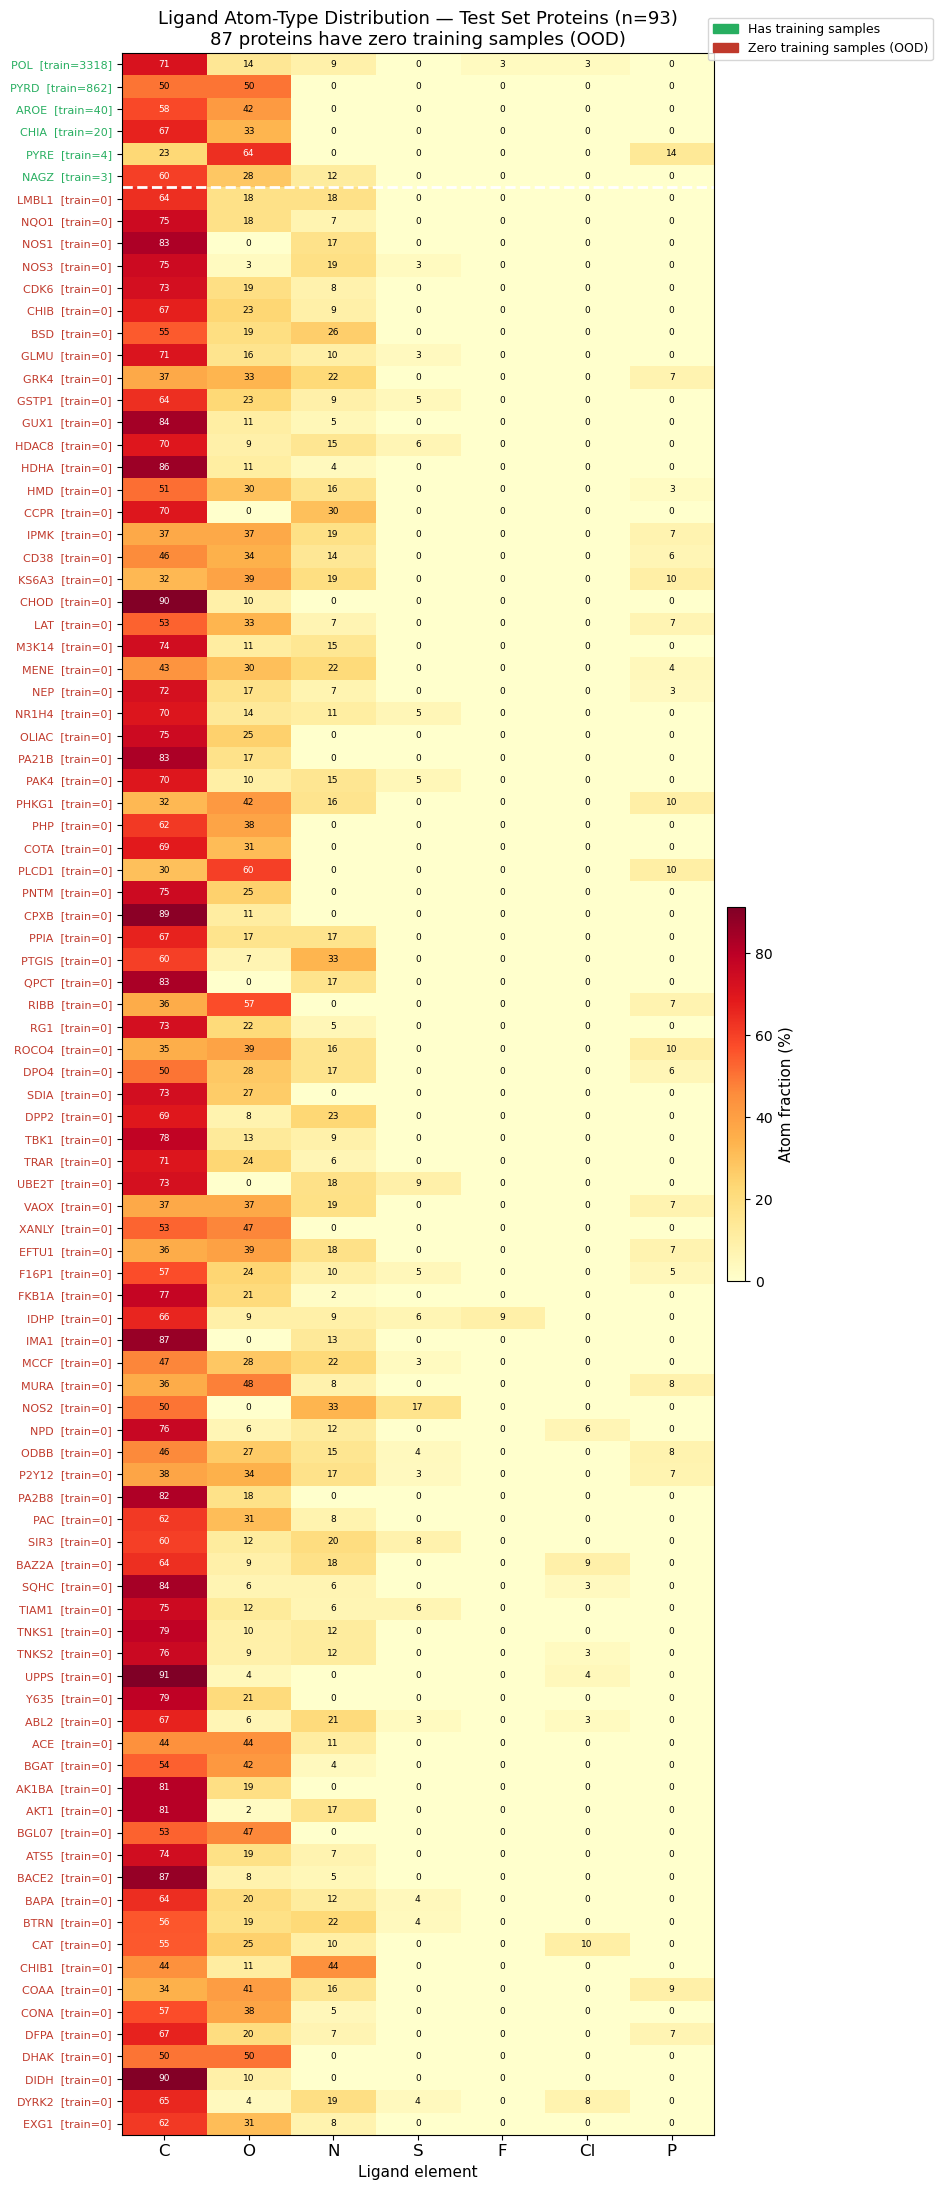

In [52]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Per-protein stats for the test set ────────────────────────────────
train_protein_counts = Counter(get_protein_name(poc['id']) for poc, lig in data_train)

test_lig_counts = defaultdict(lambda: np.zeros(N_LIGAND_ELEMENTS, dtype=np.int64))
test_sample_counts = Counter()

for poc, lig in data_test:
    prot = get_protein_name(poc['id'])
    test_sample_counts[prot] += 1
    ch = lig['atoms_channel'].numpy()
    for i in range(N_LIGAND_ELEMENTS):
        test_lig_counts[prot][i] += (ch == i).sum()

# Sort: proteins with training data first, then zero-train proteins
test_proteins_sorted = sorted(
    test_sample_counts.keys(),
    key=lambda p: (train_protein_counts.get(p, 0), test_sample_counts[p]),
    reverse=True,
)

mat_test = np.array([test_lig_counts[p] for p in test_proteins_sorted], dtype=np.float64)
mat_test_pct = mat_test / mat_test.sum(axis=1, keepdims=True) * 100

n_train_vals = [train_protein_counts.get(p, 0) for p in test_proteins_sorted]
row_labels_test = [f"{p}  [train={n}]" for p, n in zip(test_proteins_sorted, n_train_vals)]
n_test_prots = len(test_proteins_sorted)
n_zero = sum(1 for n in n_train_vals if n == 0)
n_with_train = n_test_prots - n_zero
print(f"Test proteins: {n_test_prots}  |  zero training: {n_zero}  |  has training: {n_with_train}")

# ── Heatmap ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 22))

im = ax.imshow(mat_test_pct, aspect="auto", cmap="YlOrRd")
cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Atom fraction (%)", fontsize=11)

ax.set_xticks(range(N_LIGAND_ELEMENTS))
ax.set_xticklabels(LIGAND_ELEMS, fontsize=12)
ax.set_yticks(range(n_test_prots))
ax.set_yticklabels(row_labels_test, fontsize=8)
ax.set_title(
    f"Ligand Atom-Type Distribution — Test Set Proteins (n={n_test_prots})\n"
    f"{n_zero} proteins have zero training samples (OOD)",
    fontsize=13,
)
ax.set_xlabel("Ligand element", fontsize=11)

for tick, n_tr in zip(ax.get_yticklabels(), n_train_vals):
    tick.set_color("#27ae60" if n_tr > 0 else "#c0392b")

if n_with_train > 0:
    ax.axhline(n_with_train - 0.5, color="white", lw=2, ls="--")

for i in range(n_test_prots):
    for j in range(N_LIGAND_ELEMENTS):
        val = mat_test_pct[i, j]
        text_color = "white" if val > 55 else "black"
        ax.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=6.5, color=text_color)

green_patch = mpatches.Patch(color="#27ae60", label="Has training samples")
red_patch   = mpatches.Patch(color="#c0392b", label="Zero training samples (OOD)")
ax.legend(handles=[green_patch, red_patch], loc="upper right",
          bbox_to_anchor=(1.38, 1.02), fontsize=9)

plt.tight_layout()
plt.show()
